In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import tensorflow as tf
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


2025-10-27 13:21:07.353954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761571267.539190      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761571267.605234      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/TBX11K_CVPR2020.pdf
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/README.md
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/teaser.jpg
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/code/make_json_anno.py
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/code/make_json_anno.sh
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/code/pycococreatortools.py
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/xml/tb0750.xml
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/xml/tb0500.xml
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/xml/tb0532.xml
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/xml/tb1104.xml
/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/xml/tb1113.xml
/kaggle/input/tbx11k-original-datase

In [2]:
def load_tbx11k_dataset(root_dir, list_file, img_size=(224, 224), batch_size=32):
    with open(list_file, 'r') as f:
        image_paths = [line.strip() for line in f.readlines()]

    full_paths = [os.path.join(root_dir, "imgs", p) for p in image_paths]

    class_map = {"health": 0, "sick": 1, "tb": 2}

    labels = [class_map[p.split("/")[0]] for p in image_paths]

    ds = tf.data.Dataset.from_tensor_slices((full_paths, labels))

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = img / 255.0  # normalize to [0,1]
        return img, label

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [3]:
root_dir = r"/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K"
train_list = os.path.join(root_dir, "lists", "TBX11K_train.txt")
val_list = os.path.join(root_dir, "lists", "TBX11K_val.txt")


In [4]:
train_ds = load_tbx11k_dataset(root_dir, train_list)
val_ds = load_tbx11k_dataset(root_dir, val_list)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))


Train batches: 207
Validation batches: 57


I0000 00:00:1761571302.203941      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


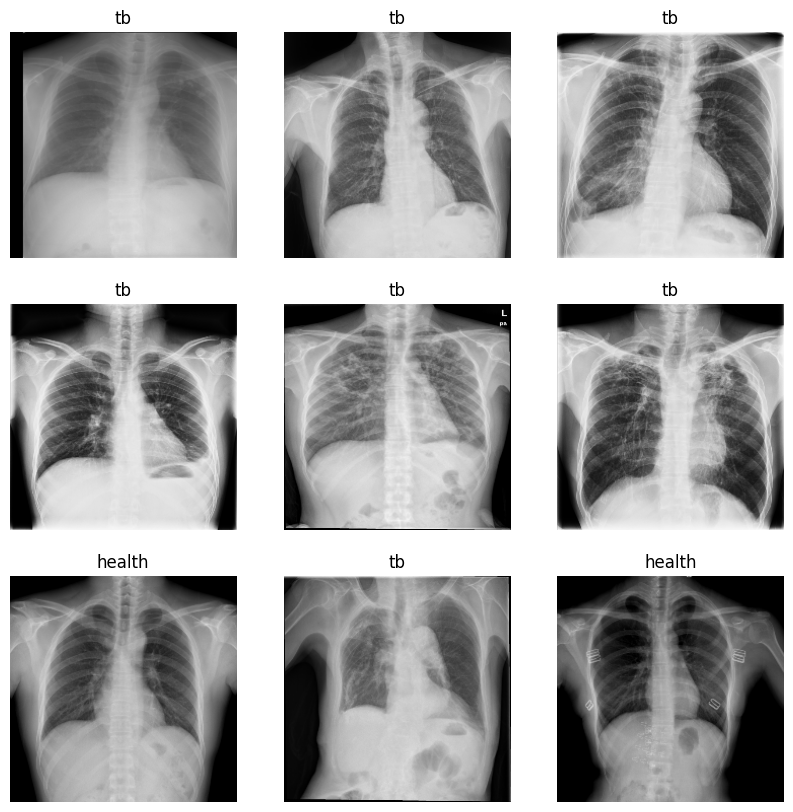

In [5]:
class_names = ["health", "sick", "tb"]

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

In [6]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [7]:
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3))

base_model.trainable = False
model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(3, activation='softmax')  
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

best_epoch = early_stop.stopped_epoch - early_stop.patience + 1

best_acc = history.history['accuracy'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]

print(f"Best epoch (chosen by EarlyStopping): {best_epoch}")
print(f"Training accuracy at best epoch: {best_acc:.4f}")
print(f"Validation accuracy at best epoch: {best_val_acc:.4f}")

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 24s 104ms/step - accuracy: 0.9676 - loss: 0.1046 - val_accuracy: 0.9478 - val_loss: 0.1888
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.9640 - loss: 0.1087 - val_accuracy: 0.9450 - val_loss: 0.1933
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.9656 - loss: 0.1134 - val_accuracy: 0.9467 - val_loss: 0.1922
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.9641 - loss: 0.0993 - val_accuracy: 0.9461 - val_loss: 0.1924
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - accuracy: 0.9608 - loss: 0.1122 - val_accuracy: 0.9489 - val_loss: 0.1838
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.9671 - loss: 0.0980 - val_accuracy: 0.9489 - val_loss: 0.1847
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.9603 - loss: 0.1198 - val_accuracy: 0.9461 - val_loss: 0.1938
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.9621 - loss: 0

In [23]:
base_model.trainable = True

fine_tune_at = 300 

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

best_epoch = early_stop.stopped_epoch - early_stop.patience + 1

best_acc = history_fine.history['accuracy'][best_epoch - 1]
best_val_acc = history_fine.history['val_accuracy'][best_epoch - 1]

print(f"Best epoch (chosen by EarlyStopping): {best_epoch}")
print(f"Training accuracy at best epoch: {best_acc:.4f}")
print(f"Validation accuracy at best epoch: {best_val_acc:.4f}")

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 133s 325ms/step - accuracy: 0.9733 - loss: 0.0876 - val_accuracy: 0.9428 - val_loss: 0.1944
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.9670 - loss: 0.0920 - val_accuracy: 0.9561 - val_loss: 0.1497
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - accuracy: 0.9536 - loss: 0.1288 - val_accuracy: 0.9422 - val_loss: 0.1965
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.9461 - loss: 0.1189 - val_accuracy: 0.9483 - val_loss: 0.1815
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.9770 - loss: 0.0800 - val_accuracy: 0.9511 - val_loss: 0.1732
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.9785 - loss: 0.0642 - val_accuracy: 0.9483 - val_loss: 0.1767
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.9750 - loss: 0.0751 - val_accuracy: 0.9567 - val_loss: 0.1578
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.9741 - loss: 

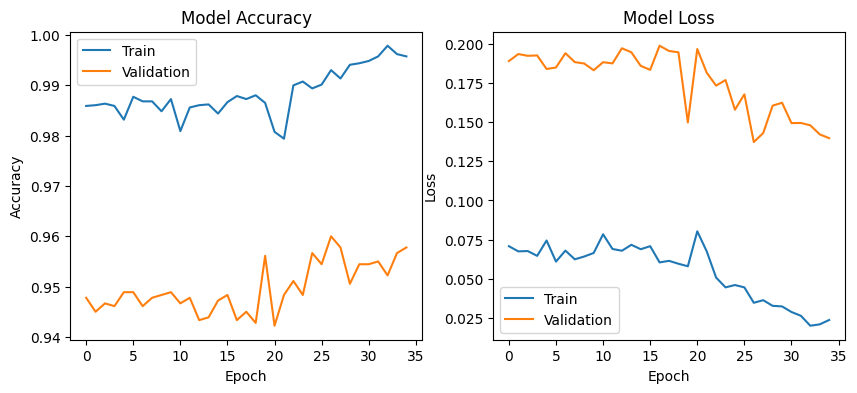

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'] + history_fine.history['loss'])
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()
